<a href="https://colab.research.google.com/github/nahid1602/Deep_Learning_Practice/blob/main/Data_Aug_Deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, models

In [2]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)
#flower_photos = folder name where it will be extracted
#origin = dataset url
#cache_dir= '.' means current directory
#untar = unzip the file

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [3]:
data_dir
#returns the directory path of the extracted file

'./datasets/flower_photos'

In [4]:
from pathlib import Path
#inorder to handel the path effiectly it is needed
data_dir = Path(data_dir)
data_dir
#PosixPath is the class used by pathlib on Unix-like systems (Linux, macOS, and also in Google Colab).

PosixPath('datasets/flower_photos')

In [5]:
#glob searches for files matching the pattern.
#*/*/*.jpg means:"Find all .jpg files in 2 folder deeper, current->sub1->sub2"
list(data_dir.glob('*/*/*.jpg'))[:3]

[PosixPath('datasets/flower_photos/flower_photos/dandelion/4714026966_93846ddb74_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/dandelion/2039797043_d5b709f275_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/dandelion/2522454811_f87af57d8b.jpg')]

In [6]:
image_count = len(list(data_dir.glob('*/*/*.jpg')))
print(image_count)

3670


In [7]:
#since there is folder name flower_photos inside a folder name flower_photos
roses = list(data_dir.glob('*/roses/*'))
roses[:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/9406573080_60eab9278e_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/172311368_49412f881b.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/118974357_0faa23cce9_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/9355706808_a9a723a8e8_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/2675221506_5286c0595f.jpg')]

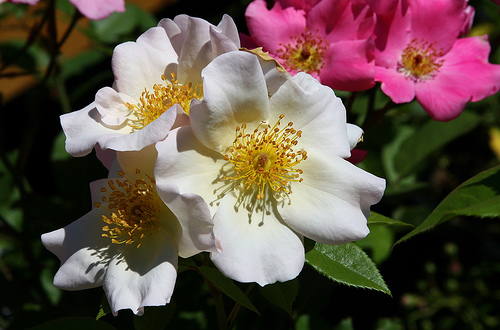

In [8]:
PIL.Image.open(str(roses[1]))

In [9]:
flowers_images_dict = {
    'roses': list(data_dir.glob('*/roses/*')),
    'daisy': list(data_dir.glob('*/daisy/*')),
    'dandelion': list(data_dir.glob('*/dandelion/*')),
    'sunflowers': list(data_dir.glob('*/sunflowers/*')),
    'tulips': list(data_dir.glob('*/tulips/*')),
}

In [10]:
flowers_images_dict


{'roses': [PosixPath('datasets/flower_photos/flower_photos/roses/9406573080_60eab9278e_n.jpg'),
  PosixPath('datasets/flower_photos/flower_photos/roses/172311368_49412f881b.jpg'),
  PosixPath('datasets/flower_photos/flower_photos/roses/118974357_0faa23cce9_n.jpg'),
  PosixPath('datasets/flower_photos/flower_photos/roses/9355706808_a9a723a8e8_n.jpg'),
  PosixPath('datasets/flower_photos/flower_photos/roses/2675221506_5286c0595f.jpg'),
  PosixPath('datasets/flower_photos/flower_photos/roses/2332478138_28f1d586e4_n.jpg'),
  PosixPath('datasets/flower_photos/flower_photos/roses/15509799653_0562d4a4fa.jpg'),
  PosixPath('datasets/flower_photos/flower_photos/roses/509239741_28e2cfe492_m.jpg'),
  PosixPath('datasets/flower_photos/flower_photos/roses/8063462557_e0a8bd6c64_n.jpg'),
  PosixPath('datasets/flower_photos/flower_photos/roses/3751835302_d5a03f55e8_n.jpg'),
  PosixPath('datasets/flower_photos/flower_photos/roses/16157873719_bf0bdf8558_n.jpg'),
  PosixPath('datasets/flower_photos/flowe

In [11]:
for key, value_list in flowers_images_dict.items():
    print(f"{key} has {len(value_list)} elements")

roses has 641 elements
daisy has 633 elements
dandelion has 898 elements
sunflowers has 699 elements
tulips has 799 elements


In [12]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [13]:
X, y = [], []
for flower_name, images in flowers_images_dict.items():
  for image in images:
    img =cv2.imread(str(image))
    resized_img = cv2.resize(img,(180,180))
    X.append(resized_img)
    y.append(flowers_labels_dict[flower_name])


In [14]:
X = np.array(X)
y = np.array(y)

In [15]:
X.shape, y.shape

((3670, 180, 180, 3), (3670,))

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [17]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

In [18]:
y_train[:5]

array([2, 0, 1, 2, 4])

In [25]:
X_train.shape

(2752, 180, 180, 3)

In [39]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.models import Sequential
cnn = Sequential([
    Conv2D(16, 3, padding ='same', activation='relu', input_shape=(180, 180, 3)),
    MaxPooling2D(), # Defaul pooling size (2,2),
    Conv2D(32, 3, padding ='same', activation='relu'),
    MaxPooling2D(),
    Conv2D(64, 3, padding ='same', activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

In [40]:
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
cnn.fit(X_train_scaled, y_train, epochs=20)

Epoch 1/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.3257 - loss: 1.5754
Epoch 2/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5016 - loss: 1.1808
Epoch 3/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.6003 - loss: 1.0078
Epoch 4/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6228 - loss: 0.9399
Epoch 5/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7000 - loss: 0.7827
Epoch 6/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7393 - loss: 0.7132
Epoch 7/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7944 - loss: 0.5799
Epoch 8/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8291 - loss: 0.4717
Epoch 9/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8608 - loss: 0.3883
Epoch 10/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8783 - loss: 0.3475
Epoch 11/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9014 - loss: 0.2751
Epoch 12/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy:

In [38]:
cnn.evaluate(X_test_scaled, y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6665 - loss: 1.4915


[1.614031195640564, 0.6612200140953064]

In [44]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

data_augmentation = Sequential([
    RandomFlip("horizontal"),     # flip images horizontally
    RandomRotation(0.1),          # rotate up to 10%
    RandomZoom(0.1),              # zoom in/out up to 10%
])
cnn = Sequential([
    data_augmentation,
    Conv2D(16, 3, padding ='same', activation='relu', input_shape=(180, 180, 3)),
    MaxPooling2D(), # Defaul pooling size (2,2),
    Conv2D(32, 3, padding ='same', activation='relu'),
    MaxPooling2D(),
    Conv2D(64, 3, padding ='same', activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2), # leaving 20% of the nodes enactive
    Dense(5, activation='softmax')
])

In [47]:
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
cnn.fit(X_train_scaled, y_train, epochs=30)


Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.8464 - loss: 0.4410
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8467 - loss: 0.3920
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.8493 - loss: 0.3825
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8678 - loss: 0.3567
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8660 - loss: 0.3597
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8763 - loss: 0.3585
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.8732 - loss: 0.3421
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8745 - loss: 0.3343
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8942 - loss: 0.2687
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.8957 - loss: 0.2880
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8875 - loss: 0.2916
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy:

In [48]:
cnn.evaluate(X_test_scaled, y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7196 - loss: 1.1354


[1.1425799131393433, 0.727668821811676]